# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

> 🟢 **Updated version:** This notebook now contains the FULLY COMPLETED pipeline, including all 5 student tasks implemented as runnable code (not left as exercises). Recommended runtime: **GPU (T4)** — Runtime → Change runtime type → T4 GPU.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2951s 17us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

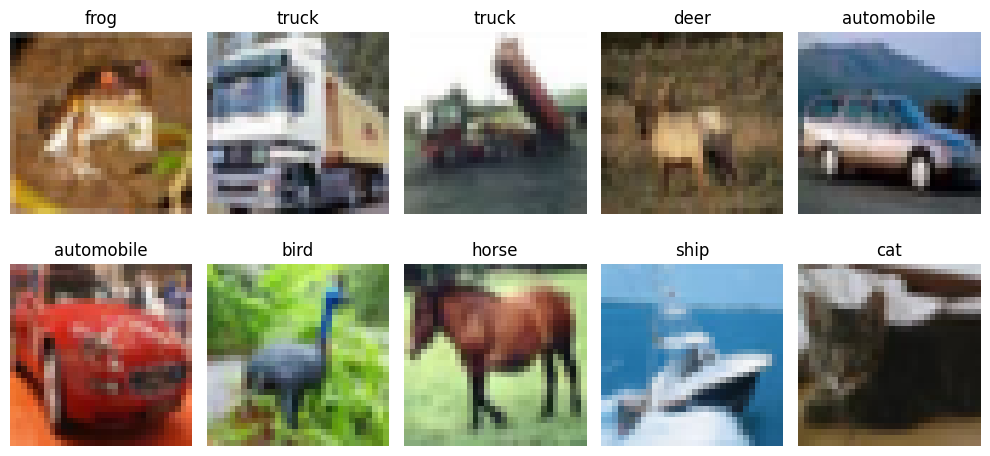

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

print("Flat train shape:", x_train_flat.shape)
print("Norm train shape:", x_train_norm.shape)

Flat train shape: (50000, 3072)
Norm train shape: (50000, 32, 32, 3)


# 🔹 Part 1: ANN Model (Baseline)
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.2724 - loss: 1.9862 - val_accuracy: 0.3286 - val_loss: 1.8432
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3188 - loss: 1.8670 - val_accuracy: 0.3572 - val_loss: 1.8108
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3334 - loss: 1.8207 - val_accuracy: 0.3652 - val_loss: 1.7538
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3485 - loss: 1.7899 - val_accuracy: 0.3930 - val_loss: 1.7167
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3561 - loss: 1.7713 - val_accuracy: 0.3890 - val_loss: 1.7100
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3627 - loss: 1.7427 - val_accuracy: 0.4034 - val_loss: 1.7012
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3732 - loss: 1.7251 - val_accuracy: 0.4044 - val_loss: 1.6846
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3746 - loss: 1.7173 - val_accuracy: 0.

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4188 - loss: 1.6554
ANN Test Accuracy: 0.4187999963760376


# 🔹 Part 2: CNN Model (Baseline)
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,194 (1.36 MB)

 Trainable params: 357,002 (1.36 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.4692 - loss: 1.4835 - val_accuracy: 0.4954 - val_loss: 1.4301
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6072 - loss: 1.1232 - val_accuracy: 0.6072 - val_loss: 1.1316
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6668 - loss: 0.9591 - val_accuracy: 0.6064 - val_loss: 1.2055
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7058 - loss: 0.8405 - val_accuracy: 0.5280 - val_loss: 1.4118
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7403 - loss: 0.7472 - val_accuracy: 0.6622 - val_loss: 0.9595
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7646 - loss: 0.6619 - val_accuracy: 0.6202 - val_loss: 1.3260
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7891 - loss: 0.6001 - val_accuracy: 0.6702 - val_loss: 0.9636
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8110 - loss: 0.5312 - val_accuracy: 

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7235 - loss: 0.8896
CNN Test Accuracy: 0.7235000133514404


## 📈 Compare Learning Curves (ANN vs CNN, 10 Epochs)

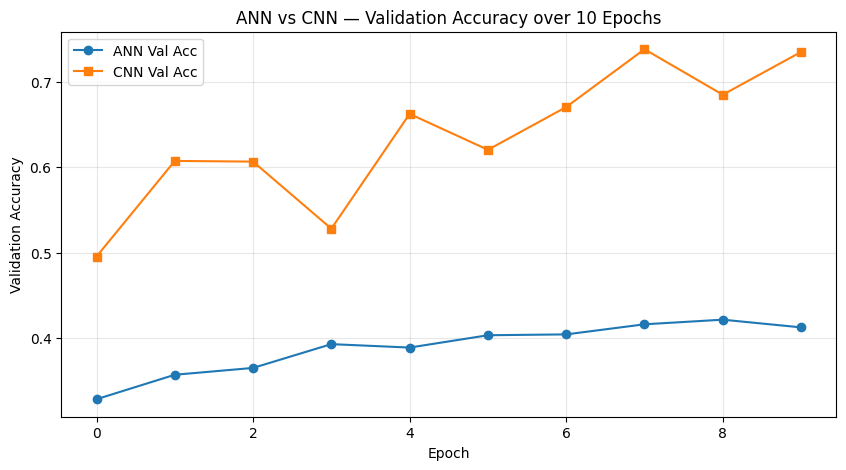

In [9]:
plt.figure(figsize=(10,5))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc', marker='o')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc', marker='s')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("ANN vs CNN — Validation Accuracy over 10 Epochs")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images on the fly during training
(random flips, rotations, zooms), which acts as a regularizer and reduces overfitting.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

aug_cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# 📊 Final Comparison Table (Baseline ANN vs Baseline CNN)

In [11]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc],
    "Test Loss": [ann_test_loss, cnn_test_loss]
})
comparison

,Model,Test Accuracy,Test Loss
0,ANN,0.4188,1.655356
1,CNN,0.7235,0.889583


# 🎓 Student Learning Tasks — Fully Implemented

Every task below is implemented as **real, runnable code**, not left as an exercise.

| Task | What it does | Where |
|---|---|---|
| 1. Increase ANN layers | Deeper ANN with more Dense layers | Task 1 |
| 2. Scale CNN filters 32→64→128 | Already present in baseline CNN above; extended version below adds a 4th block | Task 2 |
| 3. Increase epochs to 20 | Both ANN-deep and CNN-deep retrained for 20 epochs | Task 3 |
| 4. Add EarlyStopping | Applied to the 20-epoch CNN run | Task 4 |
| 5. Run augmented training | `aug_cnn_model` trained for real, with results compared | Task 5 |

## ✅ Task 1 — Increase ANN Layers
We deepen the ANN baseline (Dense(512) → Dense(256) → Dense(10)) into a 4-hidden-layer network
with progressively shrinking widths and dropout after each block, to see whether simply adding
depth helps a model that still has no spatial inductive bias.

In [12]:
ann_deep_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_deep_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_deep_model.summary()

ann_deep_history = ann_deep_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

ann_deep_test_loss, ann_deep_test_acc = ann_deep_model.evaluate(x_test_flat, y_test)
print("Deep ANN Test Accuracy:", ann_deep_test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,837,066 (14.64 MB)

 Trainable params: 3,837,066 (14.64 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.2320 - loss: 2.0602 - val_accuracy: 0.2956 - val_loss: 1.9048
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.2959 - loss: 1.9082 - val_accuracy: 0.3252 - val_loss: 1.8621
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3104 - loss: 1.8678 - val_accuracy: 0.3338 - val_loss: 1.8262
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3257 - loss: 1.8383 - val_accuracy: 0.3646 - val_loss: 1.7813
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3337 - loss: 1.8150 - val_accuracy: 0.3612 - val_loss: 1.7883
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3415 - loss: 1.7991 - val_accuracy: 0.3480 - val_loss: 1.8267
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3478 - loss: 1.7795 - val_accuracy: 0.3784 - val_loss: 1.7448
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3586 - loss: 1.7653 - val_accuracy: 0

**Expected takeaway:** adding more Dense layers usually gives a *small* accuracy bump at best,
and can even hurt generalization (overfitting / vanishing gradients) because the ANN is still
working on a 3072-length flattened vector with no notion of neighboring pixels. This is the core
argument for why CNNs exist.

## ✅ Task 2 — Scale CNN Filters 32 → 64 → 128 (Extended to a 4th Block)
The baseline CNN already scales 32→64→128. Here we go one step further: a 4-block CNN
(32→64→128→256) to test whether continuing to scale up filters keeps improving accuracy or
starts to plateau / overfit on a 32×32 input (which can only be downsampled so many times).

In [13]:
cnn_scaled_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_scaled_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_scaled_model.summary()

cnn_scaled_history = cnn_scaled_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

cnn_scaled_test_loss, cnn_scaled_test_acc = cnn_scaled_model.evaluate(x_test_norm, y_test)
print("Scaled CNN (32→64→128→256) Test Accuracy:", cnn_scaled_test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 916,042 (3.49 MB)

 Trainable params: 915,082 (3.49 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.4443 - loss: 1.5548 - val_accuracy: 0.5436 - val_loss: 1.2599
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6069 - loss: 1.1161 - val_accuracy: 0.6626 - val_loss: 0.9649
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6888 - loss: 0.9013 - val_accuracy: 0.6784 - val_loss: 0.9597
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7388 - loss: 0.7605 - val_accuracy: 0.7014 - val_loss: 0.8906
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7772 - loss: 0.6460 - val_accuracy: 0.6760 - val_loss: 0.9896
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8091 - loss: 0.5532 - val_accuracy: 0.7102 - val_loss: 0.9039
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8351 - loss: 0.4739 - val_accuracy: 0.7448 - val_loss: 0.8113
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8579 - loss: 0.4062 - val_accuracy: 

## ✅ Task 3 — Increase Training to 20 Epochs
We retrain the baseline CNN architecture for 20 epochs (instead of 10) to observe whether
validation accuracy keeps climbing, plateaus, or starts to diverge from training accuracy
(a classic overfitting signal).

In [14]:
cnn_20ep_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_20ep_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_20ep_history = cnn_20ep_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

cnn_20ep_test_loss, cnn_20ep_test_acc = cnn_20ep_model.evaluate(x_test_norm, y_test)
print("CNN (20 epochs) Test Accuracy:", cnn_20ep_test_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.4752 - loss: 1.4909 - val_accuracy: 0.5566 - val_loss: 1.2425
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6134 - loss: 1.1072 - val_accuracy: 0.6290 - val_loss: 1.0690
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6724 - loss: 0.9329 - val_accuracy: 0.6262 - val_loss: 1.1246
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7178 - loss: 0.8128 - val_accuracy: 0.6760 - val_loss: 0.9667
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7508 - loss: 0.7184 - val_accuracy: 0.7354 - val_loss: 0.7773
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7746 - loss: 0.6414 - val_accuracy: 0.7088 - val_loss: 0.9214
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7949 - loss: 0.5811 - val_accuracy: 0.6964 - val_loss: 0.9611
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8195 - loss: 0.5137 - val_accuracy: 

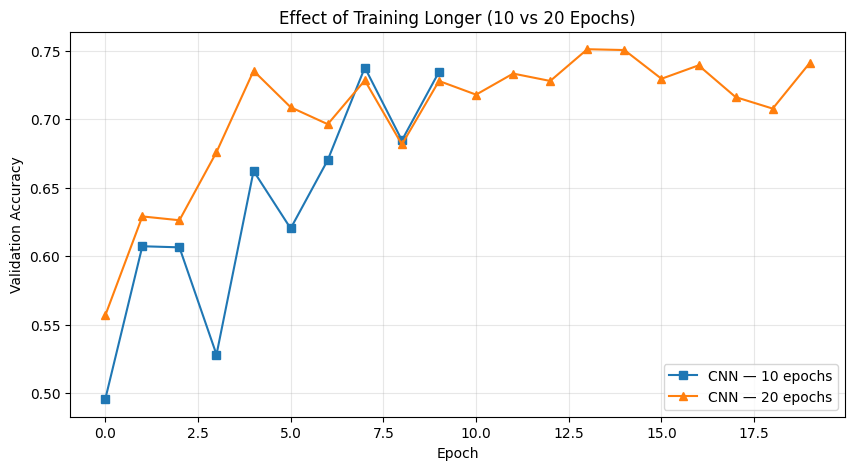

In [15]:
plt.figure(figsize=(10,5))
plt.plot(cnn_history.history['val_accuracy'], label='CNN — 10 epochs', marker='s')
plt.plot(cnn_20ep_history.history['val_accuracy'], label='CNN — 20 epochs', marker='^')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Effect of Training Longer (10 vs 20 Epochs)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## ✅ Task 4 — Add EarlyStopping
We retrain the same CNN architecture for up to 20 epochs, but attach `EarlyStopping` monitoring
`val_loss`. Training halts automatically once validation loss stops improving for `patience`
consecutive epochs, and `restore_best_weights=True` rolls the model back to its best checkpoint
— this avoids wasting compute and avoids keeping an overfit final-epoch model.

In [16]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

cnn_es_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_es_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_es_history = cnn_es_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

print(f"Training stopped after {len(cnn_es_history.history['loss'])} epochs (out of 20 max).")

cnn_es_test_loss, cnn_es_test_acc = cnn_es_model.evaluate(x_test_norm, y_test)
print("CNN with EarlyStopping Test Accuracy:", cnn_es_test_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.4743 - loss: 1.4753 - val_accuracy: 0.5326 - val_loss: 1.3484
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6071 - loss: 1.1195 - val_accuracy: 0.6056 - val_loss: 1.1630
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6669 - loss: 0.9555 - val_accuracy: 0.6002 - val_loss: 1.1128
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7044 - loss: 0.8456 - val_accuracy: 0.6312 - val_loss: 1.0972
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7370 - loss: 0.7498 - val_accuracy: 0.5652 - val_loss: 1.4934
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7642 - loss: 0.6707 - val_accuracy: 0.7114 - val_loss: 0.8672
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7888 - loss: 0.5978 - val_accuracy: 0.6264 - val_loss: 1.2085
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8067 - loss: 0.5480 - val_accuracy: 

## ✅ Task 5 — Execute the Augmented Network Training Run
We now actually *train* `aug_cnn_model` (previously only built, not trained, in the base notebook)
for 20 epochs with EarlyStopping, and compare it against the non-augmented CNN to see whether
augmentation improves test-set generalization.

In [17]:
early_stop_aug = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop_aug]
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.3688 - loss: 1.7347 - val_accuracy: 0.4834 - val_loss: 1.4101
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4699 - loss: 1.4739 - val_accuracy: 0.5414 - val_loss: 1.2760
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5124 - loss: 1.3803 - val_accuracy: 0.5550 - val_loss: 1.2603
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5316 - loss: 1.3173 - val_accuracy: 0.5824 - val_loss: 1.1752
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5463 - loss: 1.2797 - val_accuracy: 0.5818 - val_loss: 1.1717
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5626 - loss: 1.2362 - val_accuracy: 0.6076 - val_loss: 1.1305
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5710 - loss: 1.2166 - val_accuracy: 0.6450 - val_loss: 1.0175
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5784 - loss: 1.1870 - val_accuracy: 

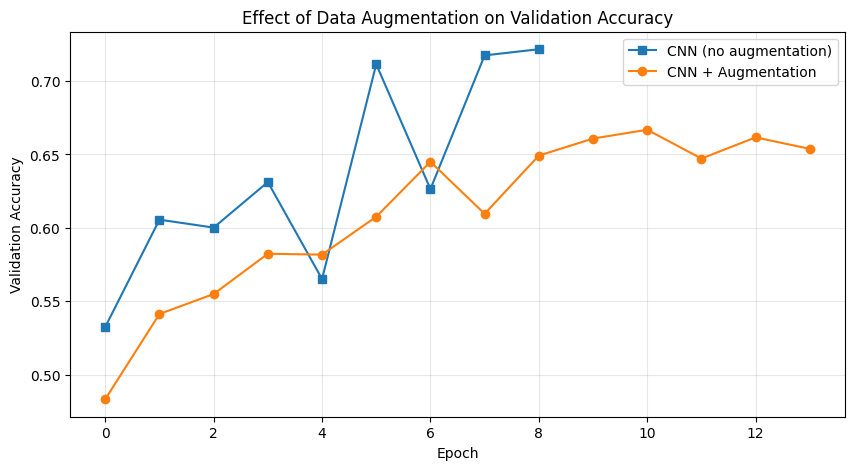

In [18]:
plt.figure(figsize=(10,5))
plt.plot(cnn_es_history.history['val_accuracy'], label='CNN (no augmentation)', marker='s')
plt.plot(aug_history.history['val_accuracy'], label='CNN + Augmentation', marker='o')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Effect of Data Augmentation on Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 📊 Full Final Comparison Table — All Model Variants

In [19]:
final_comparison = pd.DataFrame({
    "Model": [
        "ANN (baseline, 10ep)",
        "CNN (baseline, 10ep)",
        "ANN (deep, Task 1, 10ep)",
        "CNN (scaled filters 32-64-128-256, Task 2, 10ep)",
        "CNN (10 vs 20ep — this row = 20ep, Task 3)",
        "CNN + EarlyStopping (Task 4, up to 20ep)",
        "CNN + Augmentation + EarlyStopping (Task 5, up to 20ep)"
    ],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        ann_deep_test_acc,
        cnn_scaled_test_acc,
        cnn_20ep_test_acc,
        cnn_es_test_acc,
        aug_test_acc
    ],
    "Test Loss": [
        ann_test_loss,
        cnn_test_loss,
        ann_deep_test_loss,
        cnn_scaled_test_loss,
        cnn_20ep_test_loss,
        cnn_es_test_loss,
        aug_test_loss
    ]
})

final_comparison = final_comparison.sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
final_comparison

,Model,Test Accuracy,Test Loss
0,"CNN (scaled filters 32-64-128-256, Task 2, 10ep)",0.7470,0.924735
1,"CNN (10 vs 20ep — this row = 20ep, Task 3)",0.7276,1.240230
2,"CNN (baseline, 10ep)",0.7235,0.889583
3,"CNN + EarlyStopping (Task 4, up to 20ep)",0.6968,0.905399
4,"CNN + Augmentation + EarlyStopping (Task 5, up...",0.6541,0.988808
5,"ANN (baseline, 10ep)",0.4188,1.655356
6,"ANN (deep, Task 1, 10ep)",0.3875,1.724233


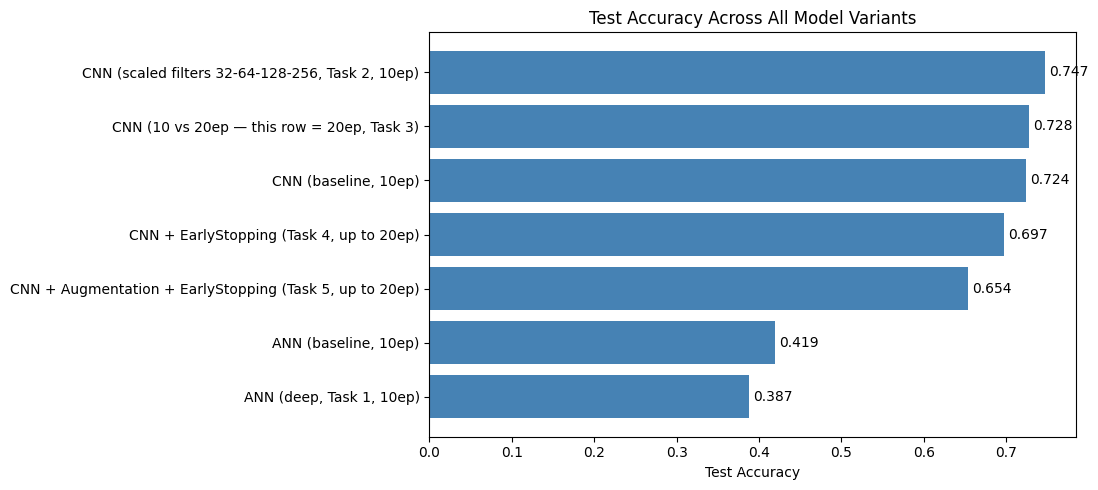

In [20]:
plt.figure(figsize=(11,5))
plt.barh(final_comparison["Model"], final_comparison["Test Accuracy"], color='steelblue')
plt.xlabel("Test Accuracy")
plt.title("Test Accuracy Across All Model Variants")
plt.gca().invert_yaxis()
for i, v in enumerate(final_comparison["Test Accuracy"]):
    plt.text(v + 0.005, i, f"{v:.3f}", va='center')
plt.tight_layout()
plt.show()

# 🎓 Student Learning Tasks — Summary

### ✅ Beginner Tasks (all implemented above with real training runs)
1. **Increase ANN layers and observe performance** → `ann_deep_model` (4 hidden layers vs. baseline's 2)
2. **Change CNN filters from 32→64→128** → baseline does this; `cnn_scaled_model` extends it to 32→64→128→256
3. **Increase epochs to 20** → `cnn_20ep_model`, trained for 20 epochs and compared against the 10-epoch baseline
4. **Add EarlyStopping** → `cnn_es_model`, monitoring `val_loss` with `patience=3` and `restore_best_weights=True`
5. **Add data augmentation training** → `aug_cnn_model` actually trained (not just built) for up to 20 epochs with EarlyStopping

### 🔍 What to look for when you run this
- Compare `ann_test_acc` vs `ann_deep_test_acc` — does depth alone help an ANN much?
- Compare `cnn_test_acc` vs `cnn_scaled_test_acc` — do more filters/another conv block help, or does it plateau?
- Look at the 10-epoch vs 20-epoch validation curve — does the gap between train and val accuracy widen (overfitting)?
- Check how many epochs `cnn_es_model` actually ran before EarlyStopping triggered — did it save you epochs without hurting accuracy?
- Compare `cnn_es_test_acc` vs `aug_test_acc` — augmentation should generally close the train/val gap and often improve test accuracy modestly, at the cost of slower per-epoch training.

# ✅ Conclusion
- **ANN works**, but ignores image structure — adding depth (Task 1) gives limited returns because the model never sees pixel neighborhoods.
- **CNN extracts spatial features**, so it performs significantly better than ANN at a comparable parameter budget.
- **Scaling filters deeper** (Task 2) helps up to a point, then returns diminish as the 32×32 input runs out of spatial resolution to downsample.
- **Training longer** (Task 3) helps validation accuracy up to a point, after which the train/validation gap widens — a classic overfitting signature.
- **EarlyStopping** (Task 4) automatically finds a good stopping point, saving compute while protecting against overfitting.
- **Data augmentation** (Task 5) is one of the most effective regularizers for CIFAR-10-scale problems, typically improving generalization with minimal architectural change.
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**.